In [1]:
from itertools import product
from pathlib import Path
from loguru import logger
from spin_lattices import TriangleLattice, SquareLattice, KagomeLattice
from heisenberg_hamiltonians import HeisenbergJ1J2
from lattice_boolean_analysis import LBFFromSpinSystem, SignedProbSignalKind, SignSignalKind
from fast_boolean_analysis import FourierSeries, fourier_expand, keep_largest_n
from collections.abc import Callable
import fire
import json
import numpy as np
from misc_utils import get_abslargest_terms
import seaborn as sns
import pandas as pd

2023-07-26 13:16:50.276 | DEBUG    | lattice_symmetries:__init__:50 - Initializing Haskell runtime...
2023-07-26 13:16:50.283 | DEBUG    | lattice_symmetries:__init__:52 - Initializing Chapel runtime...
2023-07-26 13:16:50.335 | DEBUG    | lattice_symmetries:__init__:54 - Setting Python exception handler...
set_python_exception_handler ...


In [10]:
results = []
for lattice, J2, kind in product(
    [SquareLattice(6, 4), TriangleLattice(6, 4), KagomeLattice(2, 4)],
    np.arange(0, 1.4, 0.1),
    [SignedProbSignalKind(), SignSignalKind()],
):
    system = HeisenbergJ1J2(lattice, J1=1, J2=J2, ground_state_cache_dir=Path("groundstates"))

    system.get_eigenstates(1)
    n_spins = system.number_spins

    signal = LBFFromSpinSystem(system, kind=kind)

    series = fourier_expand(signal)

    results.append(
        {
            "lattice": lattice.get_cache_id(),
            "J2": J2,
            "kind": kind.name,
            "terms_relweight": series.how_many_terms_to_achieve_relative_weight(0.2),
            "terms_signoverlap": series.how_many_terms_to_achieve_score(
                0.9, scorer="sign_overlap"
            ),
            "iipr": 1 / series.ipr(),
        }
    )

2023-07-26 13:32:08.806 | DEBUG    | heisenberg_hamiltonians:__init__:438 - use_symmetries is None and lattice is in symmetries whitelist, setting use_symmetries=True, spin_inversion=1
2023-07-26 13:32:08.807 | DEBUG    | heisenberg_hamiltonians:__init__:459 - number_spins=24
2023-07-26 13:32:08.843 | DEBUG    | heisenberg_hamiltonians:__init__:469 - Symmetry group contains 96 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-07-26 13:32:08.957 | DEBUG    | heisenberg_hamiltonians:__init__:478 - Hilbert space dimension is 15578
2023-07-26 13:32:08.984 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:67 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLattice6x4-1.0-0.0-True-1-1.pickle
2023-07-26 13:32:08.992 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:114 - Ground state energy is -66.2100551759
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-07-26 13:32:09.061 | DEBUG    | fast_boole

In [15]:
df = pd.DataFrame(results)

In [17]:
df['terms_signoverlap'] = [x[1] for x in df['terms_signoverlap']]

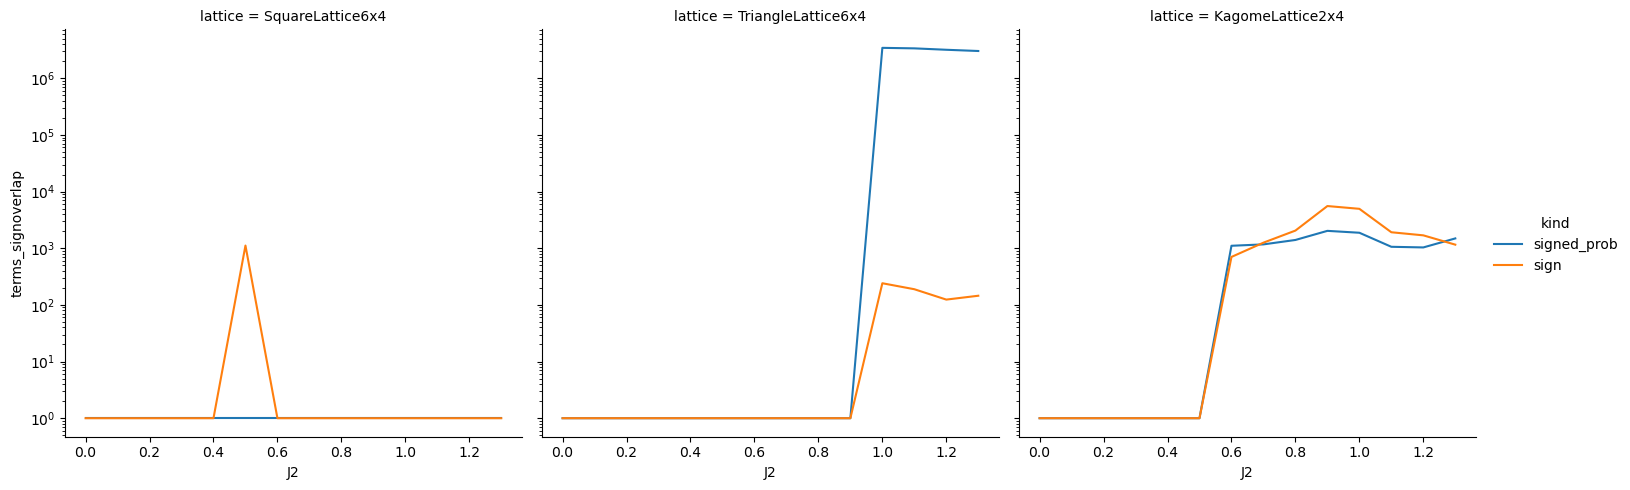

In [20]:
sns.relplot(
    data=df,
    x="J2",
    y="terms_signoverlap",
    hue="kind",
    col="lattice",
    kind="line",
    facet_kws={"sharey": True},
).set(yscale="log")